# Assignement 2

### <span style="color:chocolate"> Submission requirements </span>

Your homework will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [1]:
%pip install scikit-learn
%pip install matplotlib

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Define functions

In [2]:
def create_1d_data(num_examples, w, b, bound):
  """Create X, Y data with a linear relationship with added noise.

  Args:
    num_examples: number of examples to generate
    w: desired slope
    b: desired intercept
    bound: lower and upper boundary of the data interval

  Returns:
    X and Y with shape (num_examples)
  """
  np.random.seed(4)  # consistent random number generation
  X = np.arange(num_examples)
  deltas = np.random.uniform(low=-bound, high=bound, size=X.shape) # added noise
  Y = b + deltas + w * X

  return X, Y

---
### Step 1: Data ingestion

Let's start by creating some artificial data using the <span style="color:chocolate">create_1d_data()</span> function defined at the top of the notebook.

In [3]:
# Define parameters
num_examples = 70
w = 2
b = 1
bound = 1

# Create data
X, Y = create_1d_data(num_examples, w, b, bound)

# Print shapes
print('Printing shape of X:', X.shape)
print('Printing first 10 elements in X:', X[:10])
print('\nPrinting shape of Y:', Y.shape)
print('Printing first 10 elements in Y:', Y[:10])

Printing shape of X: (70,)
Printing first 10 elements in X: [0 1 2 3 4 5 6 7 8 9]

Printing shape of Y: (70,)
Printing first 10 elements in Y: [ 1.93405968  3.0944645   5.94536872  7.42963199  9.39545765 10.43217899
 13.95254891 14.01246051 16.50596472 18.86958306]


---
### Step 2: Data Preprocessing

Our objectives here involve adding one more feature to X and creating data partitions.

### <span style="color:chocolate">Exercise 1:</span> Adding features (10 points)

1. Add a column of $1s$ to $X$ (this will serve as an intercept or "bias" in our modeling task later on). Note: do not create a new array, just concatenate with the current values;
2. Print the shape of the array.

In [4]:
X = np.hstack((np.ones((X.shape[0], 1)), X.reshape(-1, 1)))
print("Shape of X: ", X.shape)

Shape of X:  (70, 2)


### <span style="color:chocolate">Exercise 2:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Split the (X,Y) data into training and test paritions by setting test_size=0.2 and random_state=1234. All the other arguments of the method are set to default values. Name the resulting arrays X_train, X_test, Y_train, Y_test;
2. Print the shape of each array.

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1234)

print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (56, 2)
Shape of X_test:  (14, 2)
Shape of Y_train:  (56,)
Shape of Y_test:  (14,)


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 3:</span> Plots (10 points)

Create a side-by-side histogram for the values in Y_train and X_train. Make sure to include axes name and titles for each subplot.

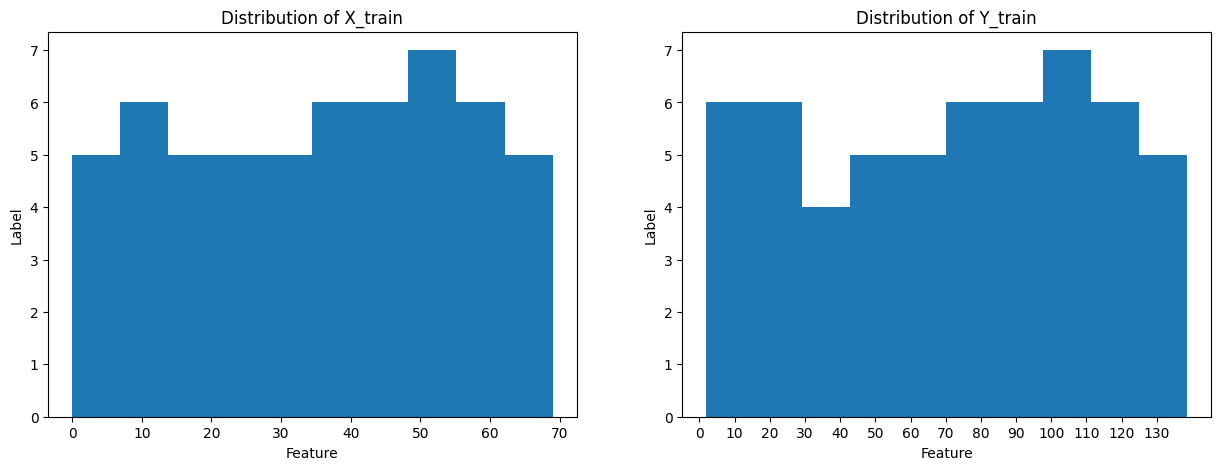

In [6]:
fig, (x_fig, y_fig) = plt.subplots(1, 2, figsize=(15, 5))

x_fig.hist(X_train[:, 1], bins=10)
x_fig.set_title('Distribution of X_train')
x_fig.set_xlabel('Feature')
x_fig.set_ylabel('Label')

y_fig.hist(Y_train, bins=10)
y_fig.set_title('Distribution of Y_train')
y_fig.set_xlabel('Feature')
y_fig.set_ylabel('Label')
# Force ticks at 10 so that it aligns to x_fig
y_fig.set_xticks(np.arange(0, 140, 10))

plt.show()

---
### Step 4: Modeling

Let's start by considering the two models proposed in Assignment 1:
1. $M_1(x) = 5+x$ 
2. $M_2(x) = 1+2x$

### <span style="color:chocolate">Exercise 4:</span> Practice with Parameters (10 points)

Perform the following computations:

1. Use matrix multiplication (np.dot) to create $M_1$ and $M_2$ (as previously defined) to produce vectors of predictions using the X_train data. Call these predictions M1_hat_train, M2_hat_train. Hint: the "learned" parameters are alredy provided to you;
3. Print the shapes of the predictions to verify that they match the shape of Y_train.

In [7]:
model1 = np.array([5, 1])
model2 = np.array([1, 2])

M1_hat_train = np.dot(X_train, model1)
M2_hat_train = np.dot(X_train, model2)

print("Shape of Y_train: ", Y_train.shape)
print("Shape of M1_hat_train: ", M1_hat_train.shape)
print("Shape of M2_hat_train: ", M2_hat_train.shape)

Shape of Y_train:  (56,)
Shape of M1_hat_train:  (56,)
Shape of M2_hat_train:  (56,)


### <span style="color:chocolate">Exercise 5:</span> Learn parameters with Gradient Descent (20 points)

1. Fill in the <span style="color:green">NotImplemented</span> parts of the <span style="color:chocolate">gradient_descent()</span> function below. Hint: refer to ``02 Linear Regression_helper.ipynb file``;

2. Run this function with our artificial (X_train, Y_train) data . Set learning_rate = .0002 and num_epochs = 5. Print out the weights and loss after each epoch. 

3. Generate a plot with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

In [8]:
num_epochs = 5
for i in range(num_epochs):
    print(i)

0
1
2
3
4


In [9]:
def gradient_descent(inputs, outputs, learning_rate, num_epochs):
  """Apply the gradient descent algorithm to learn learn linear regression.

  Args:
    inputs: A 2-D array where each column is an input feature and each
            row is a training example.
    outputs: A 1-D array containing the real-valued
             label corresponding to the input data in the same row.
    learning_rate: The learning rate to use for updates.
    num_epochs: The number of passes through the full training data.

  Returns:
    weights: A 2-D array with the learned weights after each training epoch.
    losses: A 1-D array with the loss after each epoch.
  """
  # m = number of examples, n = number of features
  m, n = inputs.shape
  
  # We'll use a vector of size n to store the learned weights and initialize
  # all weights to 1. 
  W = np.ones(n)
  
  # Keep track of the training loss and weights after each step.
  losses = []
  weights = []
  
  for epoch in range(num_epochs):
    # Append the old weights to the weights list to keep track of them.
    weights.append(W)

    # Evaluate the current predictions for the training examples given
    # the current estimate of W.
    # h_W(x) = x * W^T
    predictions = np.dot(inputs, W)
    
    # Find the difference between the predictions and the actual target
    # values.
    diff = predictions - outputs
    
    # In standard linear regression, we want to minimize the sum of squared
    # differences. Compute the mean squared error loss. Don't bother with the
    # 1/2 scaling factor here.
    loss = np.mean(diff**2)

    # Append the loss to the losses list to keep a track of it.
    losses.append(loss)
    
    # Compute the gradient with respect to the loss.
    # [Formula (4) in the Gradient Descent Implementation]
    gradient = (1/m) * np.dot(inputs.T, diff)

    # Update weights, scaling the gradient by the learning rate.
    W = W - learning_rate * gradient

    # Print out the weights and loss after each epoch. 
    print(f"Epoch {epoch}: Weights {W}, Loss {loss}")

  # Append the final weights after the loop
  weights.append(W)
      
  return np.array(weights), np.array(losses)

Epoch 0: Weights [1.00709394 1.33262886], Loss 1665.3666608648086
Epoch 1: Weights [1.01183193 1.55469157], Loss 742.4148662596615
Epoch 2: Weights [1.01499708 1.7029404 ], Loss 331.0657262384294
Epoch 3: Weights [1.01711221 1.80191116], Loss 147.73208292579974
Epoch 4: Weights [1.01852634 1.8679839 ], Loss 66.0223586320446


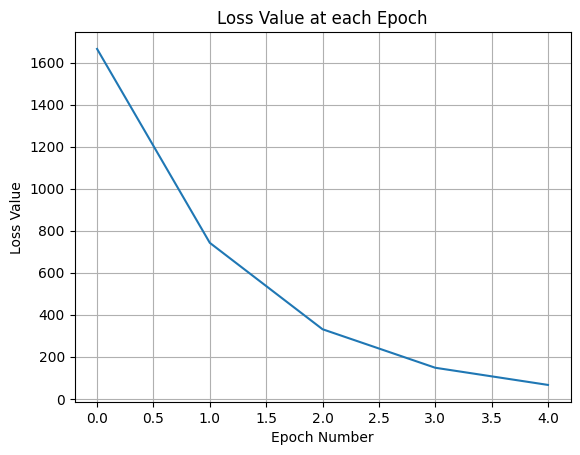

In [10]:
num_epochs = 5
learned_weights, epoch_losses = gradient_descent(X_train, Y_train, .0002, num_epochs)

plt.figure()
plt.plot(range(num_epochs), epoch_losses)
plt.title('Loss Value at each Epoch')
plt.xlabel('Epoch Number')
plt.ylabel('Loss Value')
plt.grid(True)
plt.show()

---
### Step 5: Hyperparameter tuning

Hyperparameter tuning plays an important role in optimizing ML models. One systematically adjusts hyperparameters to find the right balance between model complexity and generalization, ultimately leading to better predictive performance and model effectiveness.

Note that hyperparameter tuning is typically performed on **a separate validation dataset**. However, for the purposes of this assignment and based on the ML knowledge you've acquired thus far, we will perform hyperparameter tuning directly on the training data.

### <span style="color:chocolate">Exercise 6:</span> Tuning hyperparameters (10 points)

Answer the following questions:
    
1. Do you think it would be beneficial to extend the model training in Exercise 5 by increasing the learning rate to 0.02? Justify your answer;

2. Restoring to the previous learning_rate = .0002, would you  consider extending the model training in Exercise 5 by increasing the number of epochs to 10? Justify your answer.

Note: to support your answers, we recommend the following actions:
- create side-by-side subplots to show the loss at each epoch (make sure to include axes name and title), and
- print the loss at the last epoch under the following scenarios:
    - learning_rate=.0002, num_epochs=5;
    - learning_rate=.02, num_epochs=5;
    - learning_rate=.0002, num_epochs=10.

In [11]:
weights1, losses1 = gradient_descent(X_train, Y_train, 0.0002, 5)
weights2, losses2 = gradient_descent(X_train, Y_train, 0.02, 5)
weights3, losses3 = gradient_descent(X_train, Y_train, 0.0002, 10)

print("Final loss (lr=.0002, epochs=5):", losses1[-1])
print("Final loss (lr=.02, epochs=5):", losses2[-1])
print("Final loss (lr=.0002, epochs=10):", losses3[-1])

# 1. Do you think it would be beneficial to extend the model training in Exercise 5 by increasing the learning rate to 0.02? Justify your answer;
# No, the learning rate is too large and so we overshot the minimum and got to a divergent situation

# 2. Restoring to the previous learning_rate = .0002, would you  consider extending the model training in Exercise 5 by increasing the number of epochs to 10? Justify your answer.
# Yes, we got a much lower loss.

Epoch 0: Weights [1.00709394 1.33262886], Loss 1665.3666608648086
Epoch 1: Weights [1.01183193 1.55469157], Loss 742.4148662596615
Epoch 2: Weights [1.01499708 1.7029404 ], Loss 331.0657262384294
Epoch 3: Weights [1.01711221 1.80191116], Loss 147.73208292579974
Epoch 4: Weights [1.01852634 1.8679839 ], Loss 66.0223586320446
Epoch 0: Weights [ 1.70939419 34.26288605], Loss 1665.3666608648086
Epoch 1: Weights [  -21.14077098 -1038.13576669], Loss 1730683.4233130235
Epoch 2: Weights [  715.57111348 33536.08547039], Loss 1798911746.516617
Epoch 3: Weights [  -23036.06070114 -1081139.68066399], Loss 1869830168587.4255
Epoch 4: Weights [  742718.54314852 34856099.64525088], Loss 1943544404976516.2
Epoch 0: Weights [1.00709394 1.33262886], Loss 1665.3666608648086
Epoch 1: Weights [1.01183193 1.55469157], Loss 742.4148662596615
Epoch 2: Weights [1.01499708 1.7029404 ], Loss 331.0657262384294
Epoch 3: Weights [1.01711221 1.80191116], Loss 147.73208292579974
Epoch 4: Weights [1.01852634 1.867983

### <span style="color:chocolate">Exercise 7:</span> Choosing the best model (10 points)

Write down the learned model that you consider most optimal given your answers to the hyperparameter tuning exercise. Call this model $M_3(x)$.

In [12]:
# Model 3 is not the lowest error. This is the model based on the gradient descent
# $M_3(x) = 1.02101022 + 1.98308738x$
print("Parameters of Model 3: ", weights3[-1])
model3 = weights3[-1]

Parameters of Model 3:  [1.02101022 1.98308738]


---
### Step 6: Evaluation and Generalization

To evaluate our models, we assess their performance based on how closely they fit the available data. In other words, we compare the true value $y$ with the predicted value $\hat{y}$ for each $x$.

### <span style="color:chocolate">Exercise 8:</span> Computing MSE (10 points)

Assess the performance of the three models ($M_1(x)$, $M_2(x)$, $M_3(x)$) by computing the MSE metric on the training dataset. Hint: you can use the <span style="color:chocolate">mean_squared_error()</span> method available in sklearn.metrics.

In [13]:
M3_hat_train = np.dot(X_train, model3)

mse_model1_train = mean_squared_error(Y_train, M1_hat_train)
mse_model2_train = mean_squared_error(Y_train, M2_hat_train)
mse_model3_train = mean_squared_error(Y_train, M3_hat_train)

print("MSE of M1 (training data): ", mse_model1_train)
print("MSE of M2 (training data): ", mse_model2_train)
print("MSE of M3 (training data): ", mse_model3_train)

MSE of M1 (training data):  1397.608983658733
MSE of M2 (training data):  0.3280557752885262
MSE of M3 (training data):  0.8393687909121693


### <span style="color:chocolate">Exercise 9:</span> Generalization (10 points)

Which of the three models ($M_1(x)$, $M_2(x)$, $M_3(x)$) demonstrates better generalization ability? Hint: compare training vs. test MSE.

In [14]:
M1_hat_test = np.dot(X_test, model1)
M2_hat_test = np.dot(X_test, model2)
M3_hat_test = np.dot(X_test, model3)

mse_model1_test = mean_squared_error(Y_test, M1_hat_test)
mse_model2_test = mean_squared_error(Y_test, M2_hat_test)
mse_model3_test = mean_squared_error(Y_test, M3_hat_test)

print("MSE of M1 (testing data): ", mse_model1_test)
print("MSE of M2 (testing data): ", mse_model2_test)
print("MSE of M3 (testing data): ", mse_model3_test)

# Both models 2 and 3 generalizes well. However, Model 2 is the best model because it has the lowest MSE in both the training and test data sets.

MSE of M1 (testing data):  1113.6003911560044
MSE of M2 (testing data):  0.2908006971666422
MSE of M3 (testing data):  0.6026016556635998


----
### <span style="color:chocolate">Exercise 10:</span> Additional practice (not graded)

1. How does stochastic gradient descent (SGD) differ from the gradient descent (GD) approach implemented in Exercise 5?
2. Determine the optimal weights for model $M_3(x)$ using SGD. Does SGD converge more rapidly? Explain the reasons for your answer.

In [15]:
# YOUR ANSWER HERE

In [16]:
# YOUR CODE HERE